In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D

In [2]:
# Parametros de los graficos
xsize = 7*0.8
ysize = 4*0.8
alp = 0.2

In [5]:
# Ruta al archivo
file_path = "./Integral_sol/Energias_e1h2.csv"

# Cargar el archivo en un DataFrame, ignorando las líneas que comienzan con '%'
df = pd.read_csv(file_path, comment='%', header=None, delim_whitespace=True)

# Asignar nombres a las columnas
df.columns = ['l1', 'l2', 'm', 'B0', 'E0', 'h1', 'Integration_1_meV']

# Mostrar las primeras filas del DataFrame
print(df.head())

   l1  l2  m  B0        E0   h1  Integration_1_meV
0   2   1 -1   0 -10000000  0.1           4.306848
1   2   1 -1   0 -10000000  0.3           4.304459
2   2   1 -1   0 -10000000  0.5           4.302935
3   2   1 -1   0 -10000000  0.7           4.301947
4   2   1 -1   0 -10000000  0.9           4.299062


/var/folders/89/43ylvgyx5hj4v_z5nn_dl1980000gn/T/ipykernel_74856/2480112563.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, comment='%', header=None, delim_whitespace=True)


In [6]:
# Ruta al archivo
file_path = "./Integral_sol/Energias_e1h2.csv"

# Cargar el archivo en un DataFrame, ignorando las líneas que comienzan con '%'
df = pd.read_csv(file_path, delim_whitespace=True, comment='%', header=None)

# Asignar nombres a las columnas
df.columns = ['l1', 'l2', 'm', 'B0', 'E0', 'h1', 'Coulomb']

# Convertir las columnas necesarias a tipo numérico
df['h1'] = pd.to_numeric(df['h1'], errors='coerce')
df['E0'] = pd.to_numeric(df['E0'], errors='coerce')
df['B0'] = pd.to_numeric(df['B0'], errors='coerce')

# Mostrar las primeras filas del DataFrame
print(df.head())


   l1  l2  m  B0        E0   h1   Coulomb
0   2   1 -1   0 -10000000  0.1  4.306848
1   2   1 -1   0 -10000000  0.3  4.304459
2   2   1 -1   0 -10000000  0.5  4.302935
3   2   1 -1   0 -10000000  0.7  4.301947
4   2   1 -1   0 -10000000  0.9  4.299062


/var/folders/89/43ylvgyx5hj4v_z5nn_dl1980000gn/T/ipykernel_74856/1961226890.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, comment='%', header=None)


In [7]:
# Obtener valores únicos de `m` y `B0`
unique_m = df['m'].unique()
unique_B0 = df['B0'].unique()
unique_E0 = df['E0'].unique()

print(unique_m)
print(unique_B0)
print(unique_E0)

[-1  0  1]
[ 0  5 10 20 30]
[-10000000  -5000000         0   5000000  10000000]


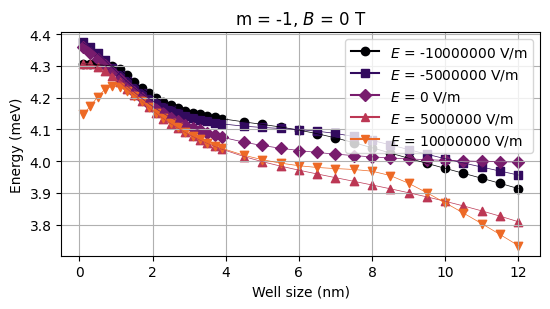

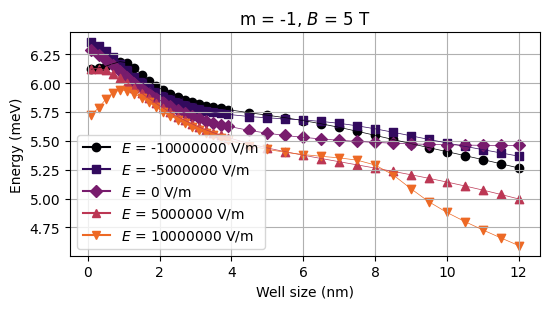

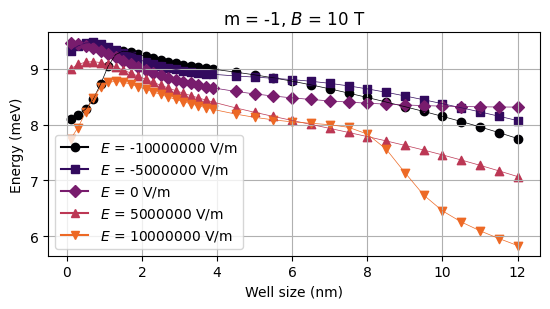

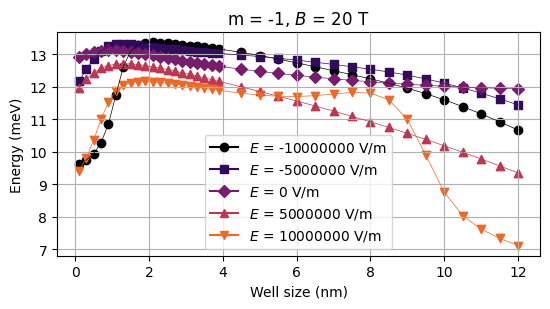

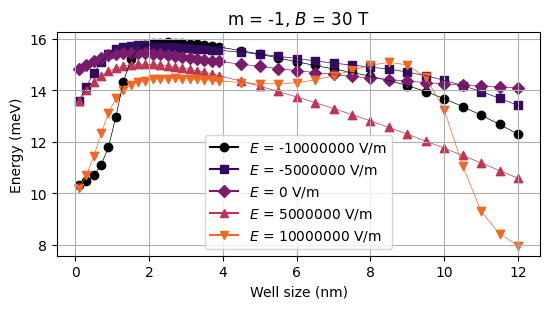

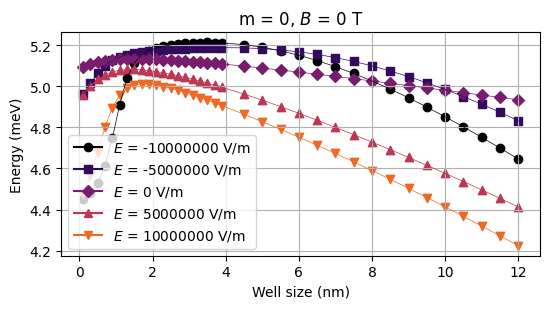

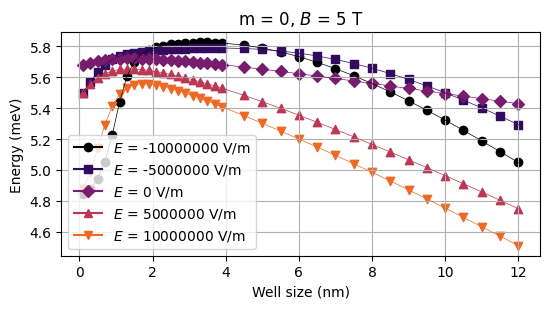

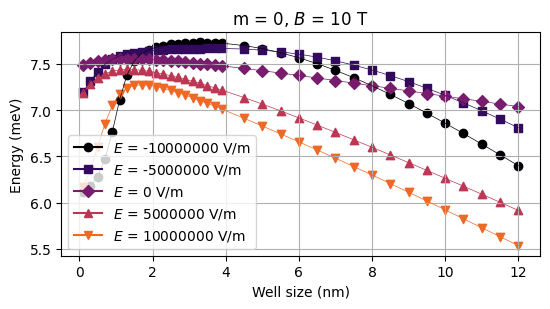

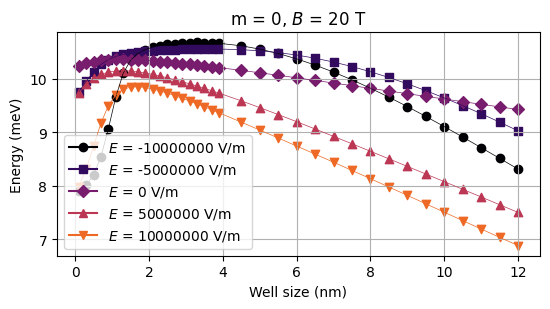

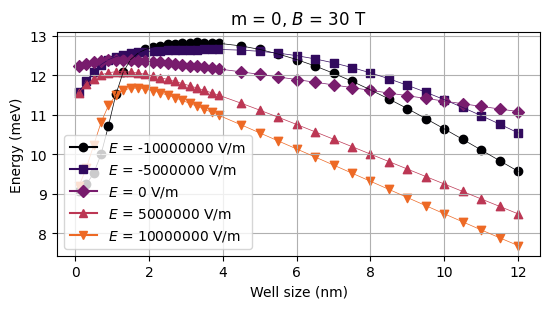

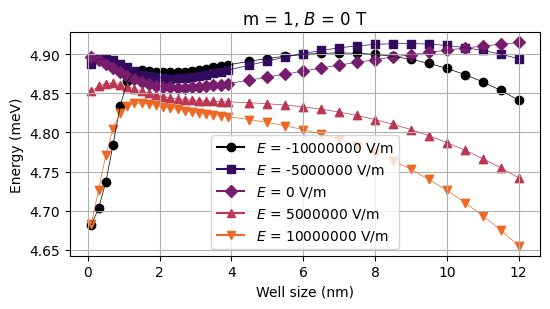

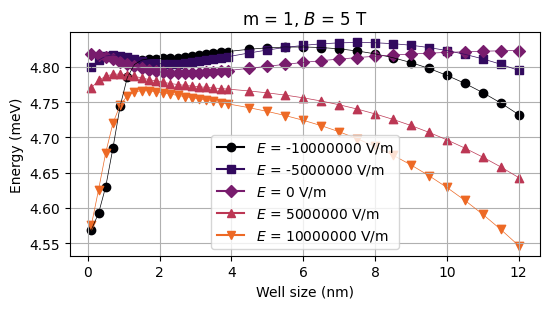

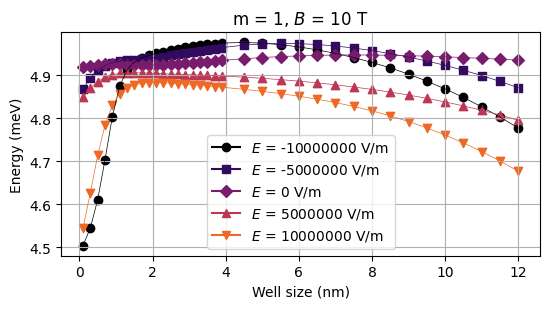

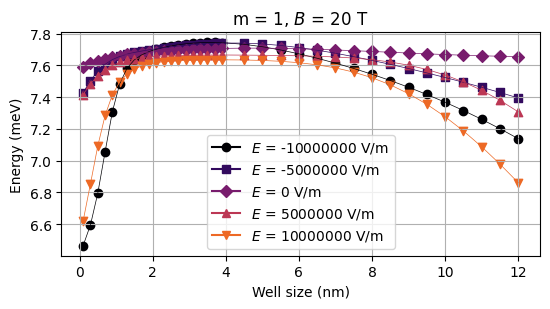

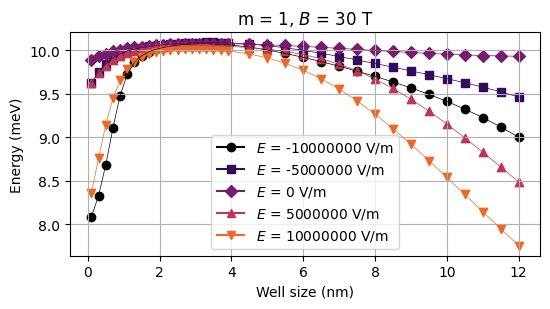

In [8]:

for m_value in unique_m:
    for B0_value in unique_B0:

        # Crear la figura
        plt.figure(figsize=(xsize, ysize))
        #cmap = plt.cm.get_cmap("viridis", len(unique_B0) + 2)  # Colormap similar al estilo deseado
        cmap = plt.get_cmap("inferno", len(unique_E0) + 2)  # Colormap similar al estilo deseado
        markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H', 'X', 'd']  # Lista de marcadores

        for i, E0_value in enumerate(unique_E0):
            subset = df[(df['m'] == m_value) & (df['B0'] == B0_value) & (df['E0'] == E0_value)]
            # print(subset.head())

            if not subset.empty:
                marker = markers[i % len(markers)]  # Asignar marcador basado en el índice de B0
                # Graficar con marcadores solo para valores de cada 5 nm en la columna 3
                plt.plot(subset['h1'], subset['Coulomb'], linestyle='-', lw=.5, color=cmap(i), label=f"$E$ = {E0_value} V/m")
                plt.scatter(subset['h1'], subset['Coulomb'], color=cmap(i), marker=marker)  # Marcadores solo para múltiplos de 5 nm

        # Etiquetas y título
        plt.xlabel("Well size (nm)")
        plt.ylabel("Energy (meV)")
        plt.title(f"m = {m_value}, $B$ = {B0_value} T")
        #plt.title("Curvas para diferentes valores de B0")
        #plt.xlim(10, 200)
        plt.grid(True)
        plt.legend()

        # Mostrar la gráfica con leyenda que incluya el marcador
        handles, labels = plt.gca().get_legend_handles_labels()
        new_handles = []
        for handle, label in zip(handles, labels):
            marker = markers[unique_E0.tolist().index(float((label.split('=')[1]).split('V/m')[0].strip())) % len(markers)]
            new_handles.append(plt.Line2D([], [], color=handle.get_color(), marker=marker, linestyle='-', label=label))
        plt.legend(handles=new_handles)
        #plt.show()

        # Guardar la gráfica
        plt.tight_layout()
        # plt.savefig(f"output/graph_m{m_value}_B0{B0_value}.pdf", format="pdf", bbox_inches="tight")


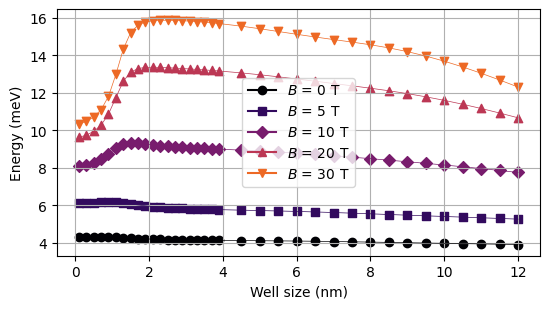

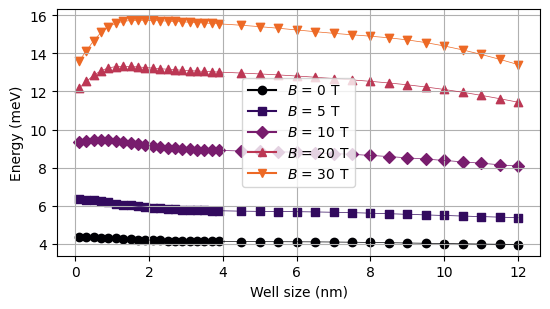

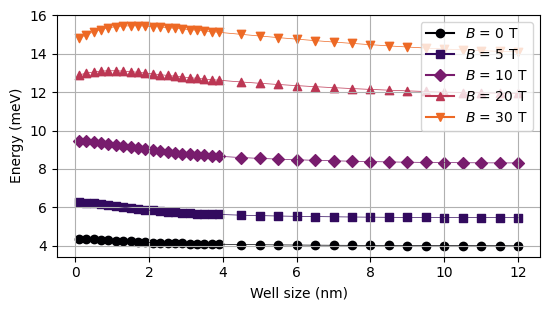

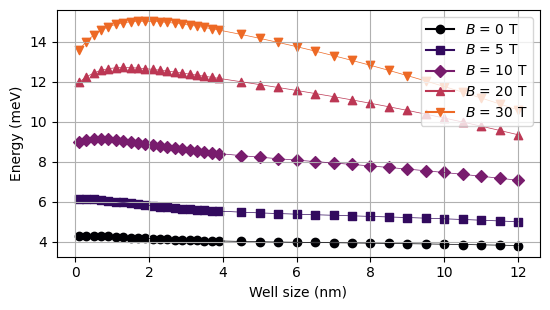

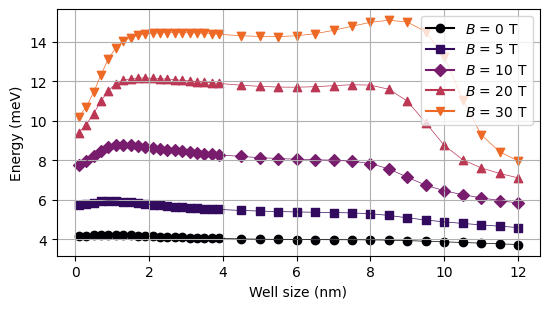

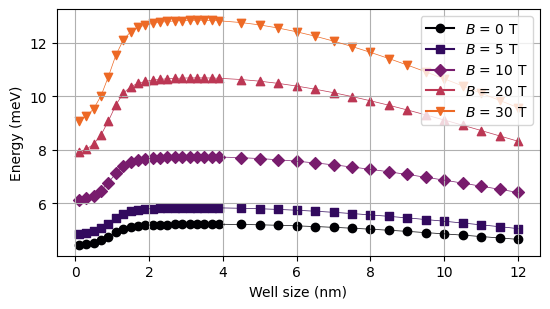

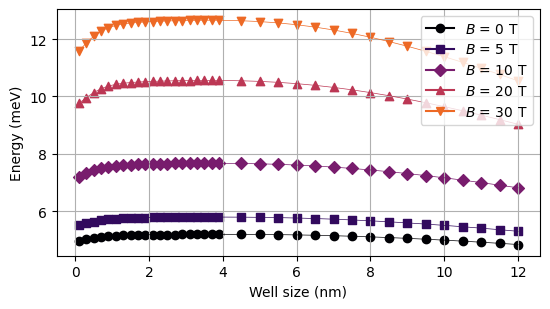

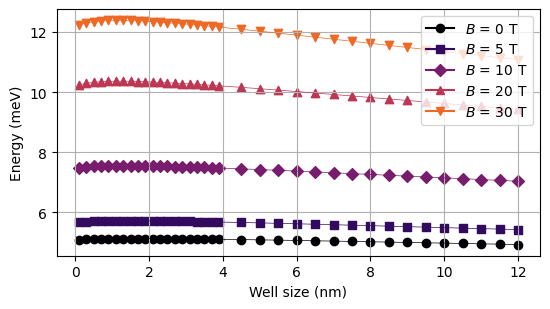

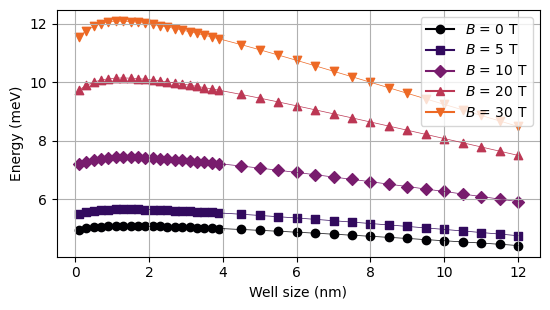

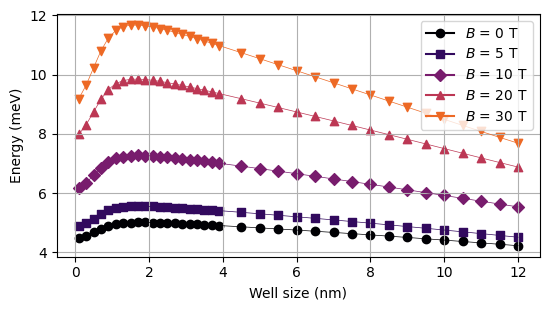

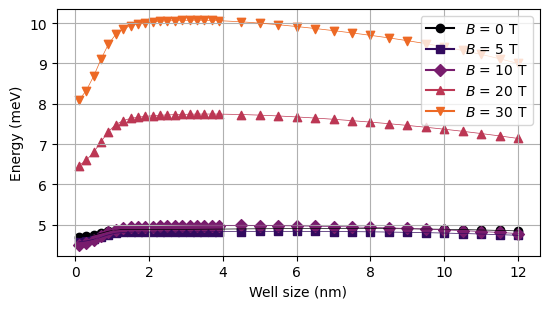

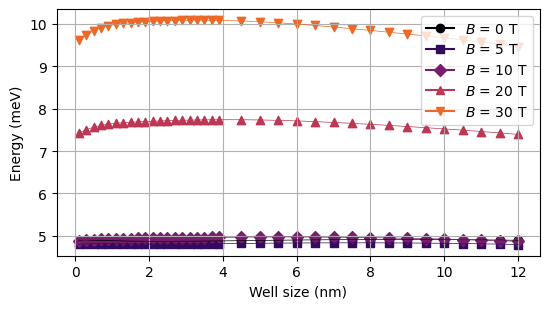

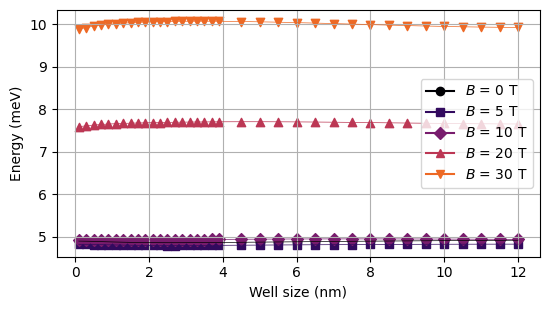

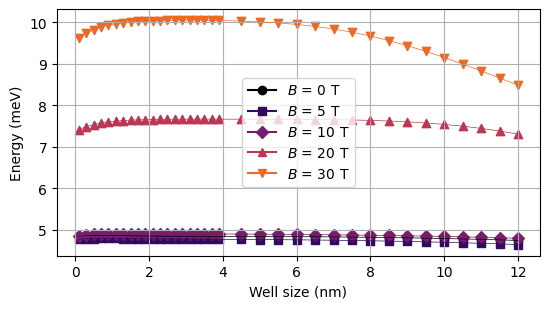

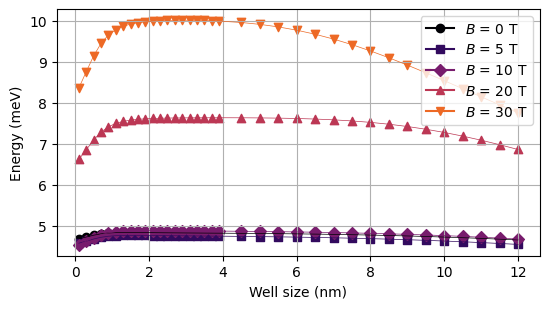

In [9]:
for m_value in unique_m:
    for E0_value in unique_E0:

        # Crear la figura
        plt.figure(figsize=(xsize, ysize))
        # cmap = plt.cm.get_cmap("viridis", len(unique_E0) + 2)  # Colormap similar al estilo deseado
        cmap = plt.get_cmap("inferno", len(unique_B0) + 2)  # Colormap similar al estilo deseado
        markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H', 'X', 'd']  # Lista de marcadores

        for i, B0_value in enumerate(unique_B0):
            subset = df[(df['m'] == m_value) & (df['E0'] == E0_value) & (df['B0'] == B0_value)]
            # print(subset.head())

            if not subset.empty:
                marker = markers[i % len(markers)]  # Asignar marcador basado en el índice de B0
                # Graficar con marcadores solo para valores de cada 5 nm en la columna 3
                plt.plot(subset['h1'], subset['Coulomb'], linestyle='-', lw=.5, color=cmap(i), label=f"$B$ = {B0_value} T")
                plt.scatter(subset['h1'], subset['Coulomb'], color=cmap(i), marker=marker)  # Marcadores solo para múltiplos de 5 nm

        # Etiquetas y título
        plt.xlabel("Well size (nm)")
        plt.ylabel("Energy (meV)")
        #plt.title(f"m = {m_value}, $E$ = {E0_value} V/m")
        #plt.xlim(10, 200)
        plt.grid(True)
        plt.legend()

        # Mostrar la gráfica con leyenda que incluya el marcador
        handles, labels = plt.gca().get_legend_handles_labels()
        new_handles = []
        for handle, label in zip(handles, labels):
            marker = markers[unique_B0.tolist().index(float((label.split('=')[1]).split('T')[0].strip())) % len(markers)]
            new_handles.append(plt.Line2D([], [], color=handle.get_color(), marker=marker, linestyle='-', label=label))
        plt.legend(handles=new_handles)

        # Guardar la gráfica
        plt.tight_layout()
        #plt.savefig(f"output/graph_m{m_value}_E0{E0_value}.pdf", format="pdf", bbox_inches="tight")
        

/var/folders/89/43ylvgyx5hj4v_z5nn_dl1980000gn/T/ipykernel_74856/2752216063.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(xsize, ysize))


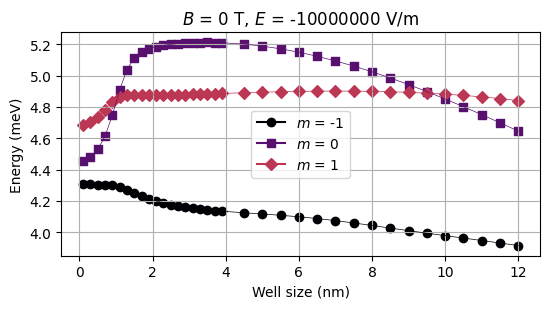

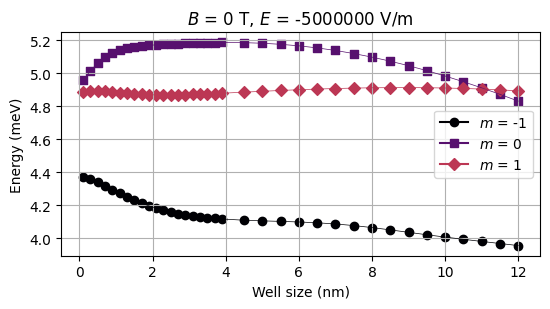

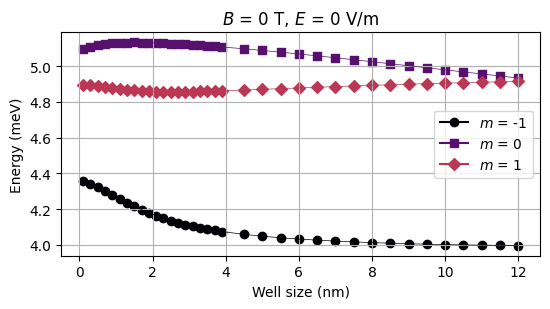

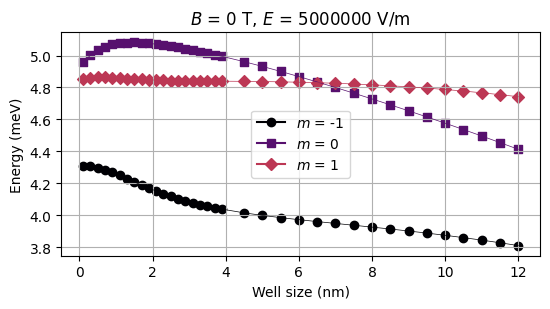

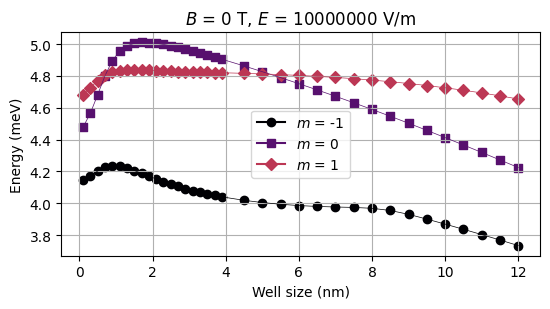

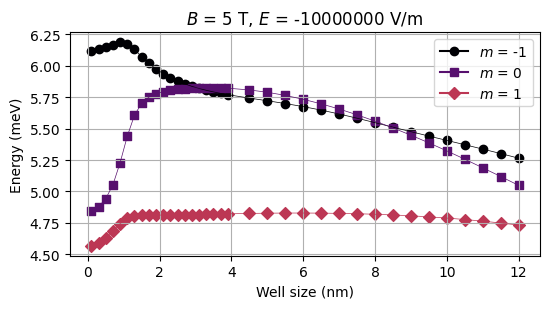

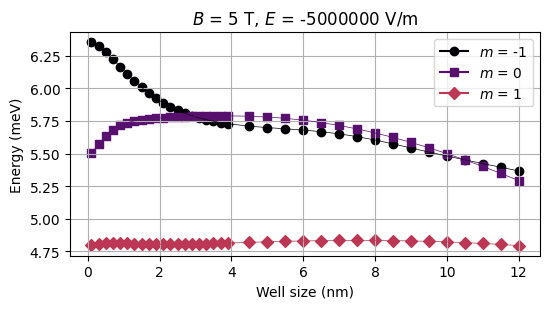

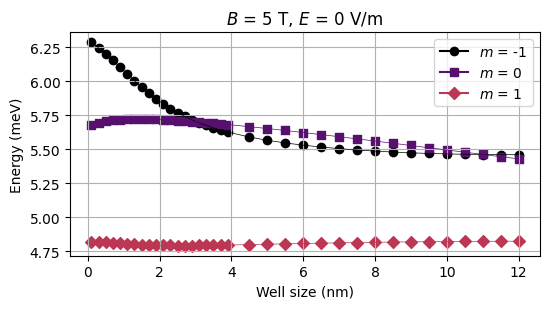

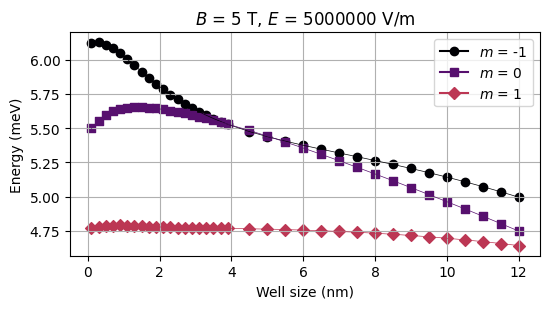

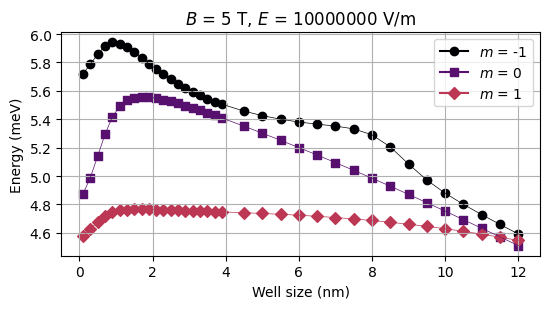

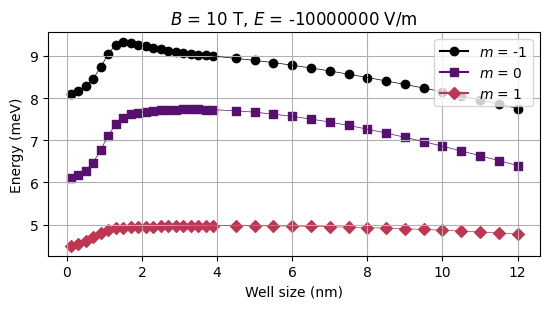

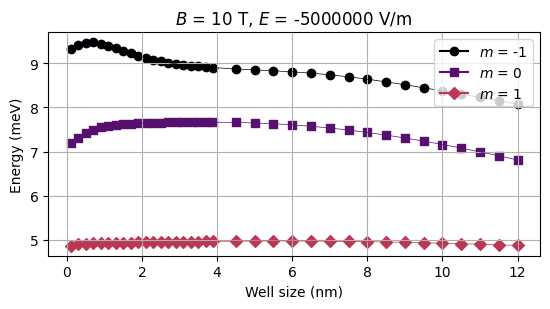

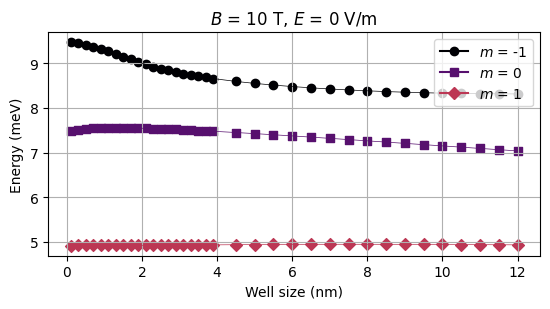

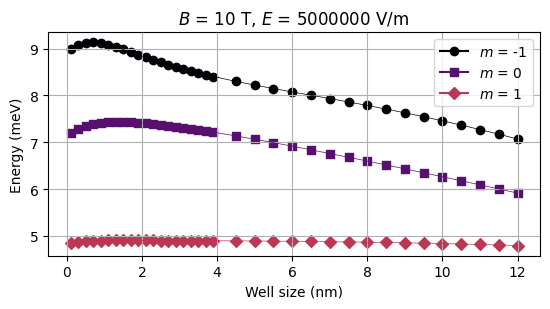

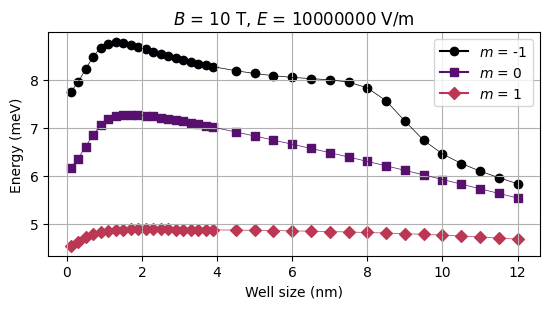

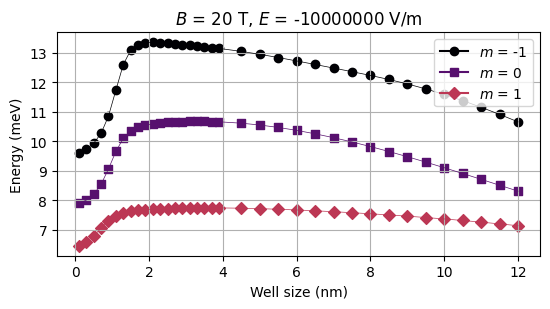

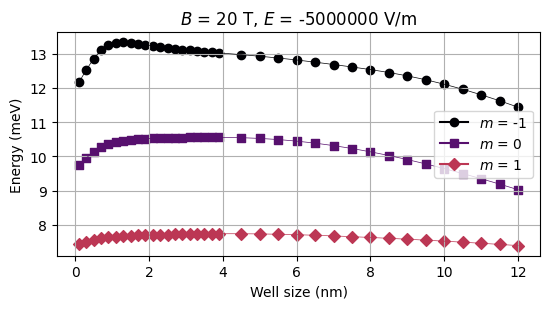

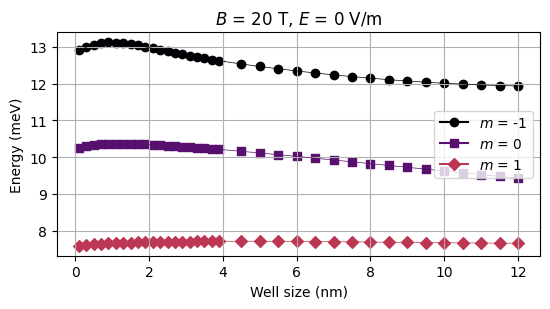

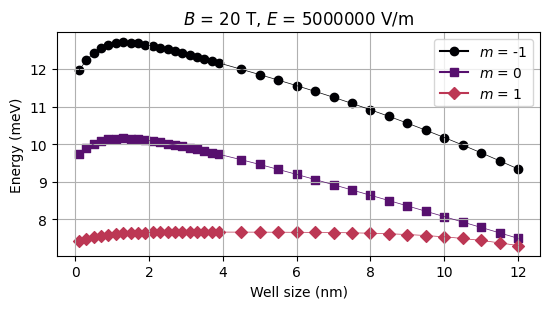

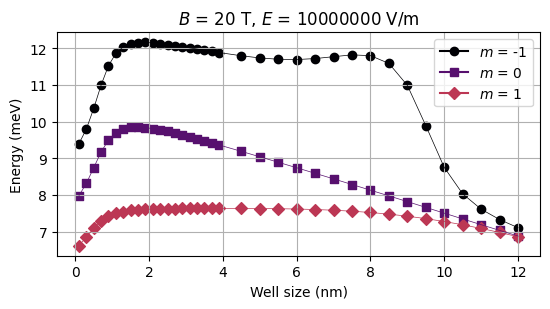

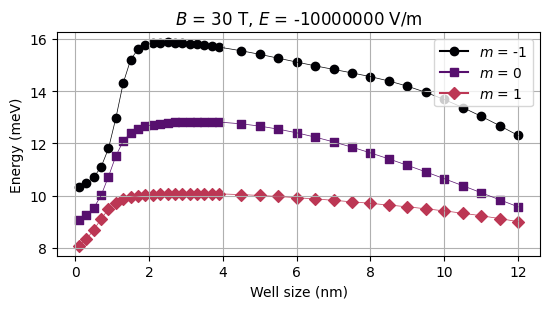

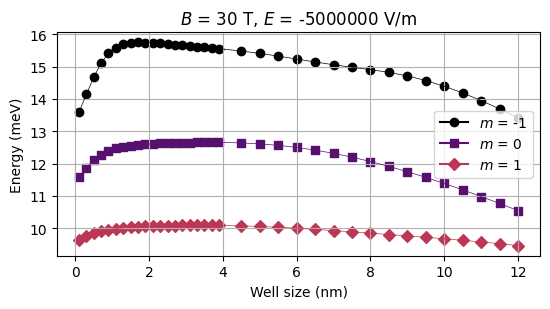

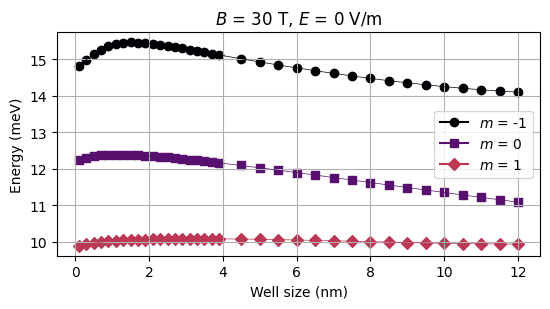

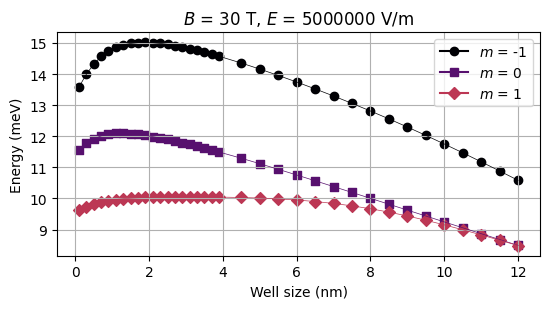

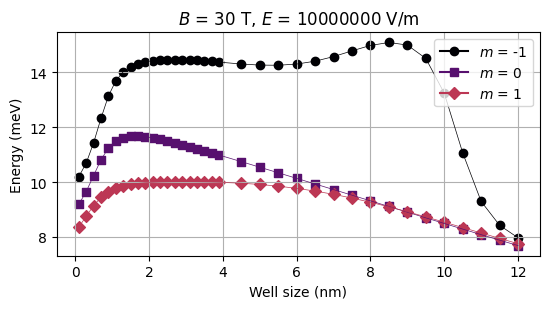

In [10]:
for B0_value in unique_B0:
    for E0_value in unique_E0:

        # Crear la figura
        plt.figure(figsize=(xsize, ysize))
        # cmap = plt.cm.get_cmap("viridis", len(unique_m) + 2)  # Colormap similar al estilo deseado
        cmap = plt.get_cmap("inferno", len(unique_m) + 2)  # Colormap similar al estilo deseado
        markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H', 'X', 'd']  # Lista de marcadores

        for i, m_value in enumerate(unique_m):
            subset = df[(df['m'] == m_value) & (df['B0'] == B0_value) & (df['E0'] == E0_value)]
            # print(subset.head())

            if not subset.empty:
                marker = markers[i % len(markers)]  # Asignar marcador basado en el índice de `m`
                # Graficar con marcadores solo para valores de cada 5 nm en la columna `h1`
                plt.plot(subset['h1'], subset['Coulomb'], linestyle='-', lw=.5, color=cmap(i), label=f"$m$ = {m_value}")
                plt.scatter(subset['h1'], subset['Coulomb'], color=cmap(i), marker=marker)  # Marcadores solo para múltiplos de 5 nm

        # Etiquetas y título
        plt.xlabel("Well size (nm)")
        plt.ylabel("Energy (meV)")
        plt.title(f"$B$ = {B0_value} T, $E$ = {E0_value} V/m")
        #plt.xlim(10, 200)
        plt.grid(True)
        plt.legend()

        # Mostrar la gráfica con leyenda que incluya el marcador
        handles, labels = plt.gca().get_legend_handles_labels()
        new_handles = []
        for handle, label in zip(handles, labels):
            marker = markers[unique_m.tolist().index(float((label.split('=')[1]).strip())) % len(markers)]
            new_handles.append(plt.Line2D([], [], color=handle.get_color(), marker=marker, linestyle='-', label=label))
        plt.legend(handles=new_handles)

        # Guardar la gráfica
        plt.tight_layout()
        # plt.savefig(f"output/graph_B0{B0_value}_E0{E0_value}.pdf", format="pdf", bbox_inches="tight")

# Proceso para graficar una matrix de las energias de exitones

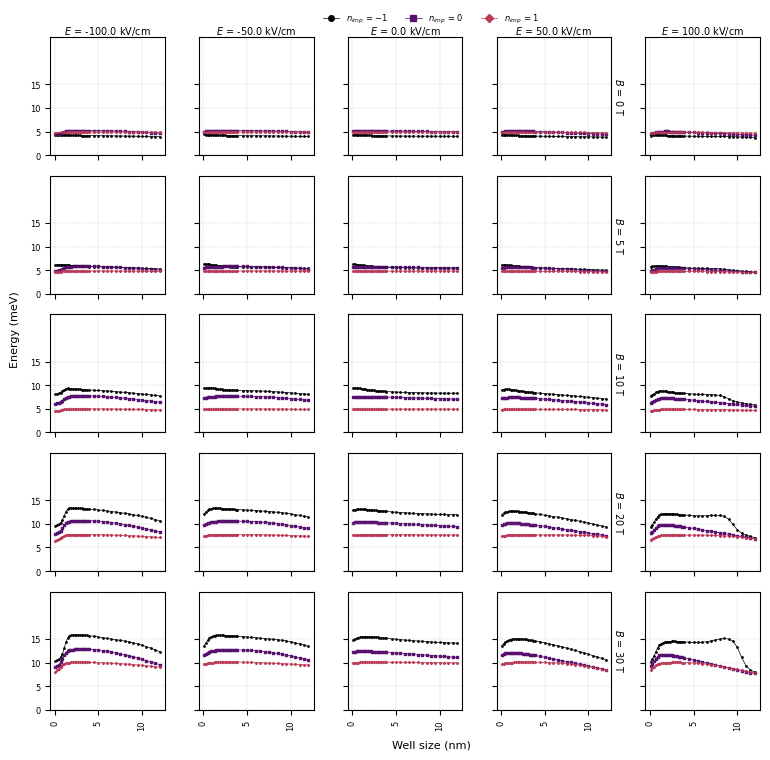

In [11]:
# Tamaño de figura para 12 cm de ancho (≈ 4.72 pulgadas)
figsize = (8, 8)
fig, axes = plt.subplots(5, 5, figsize=figsize, sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.05, wspace=0.05)

cmap = plt.get_cmap("inferno", len(unique_m) + 2)
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H', 'X', 'd']

for i, B0_value in enumerate(unique_B0):
    for j, E0_value in enumerate(unique_E0):
        ax = axes[i, j]

        for k, m_value in enumerate(unique_m):
            subset = df[(df['m'] == m_value) & (df['B0'] == B0_value) & (df['E0'] == E0_value)]
            if not subset.empty:
                color = cmap(k)
                marker = markers[k % len(markers)]
                ax.plot(subset['h1'], subset['Coulomb'], linestyle='-', lw=0.5, color=color)
                ax.scatter(subset['h1'], subset['Coulomb'], color=color, marker=marker, s=1)

        #ax.set_xlim(10, 200)
        ax.set_ylim(0, 25)
        ax.grid(True, linewidth=0.3, linestyle='--', alpha=0.7)
        ax.tick_params(labelsize=6)
        #ax.set_xticks(np.linspace(20, 180, 5))
        ax.set_yticks(np.linspace(0, 15, 4))

        for label in ax.get_xticklabels():
            label.set_rotation(90)
            label.set_ha('center')

        if i == 0:
            ax.set_title(f"$E$ = {E0_value/100000} kV/cm", fontsize=7, pad=2)
        if j == 3:
            ax.text(1.02, 0.5, f"$B$ = {B0_value} T", transform=ax.transAxes,
                    fontsize=7, va='center', ha='left', rotation=270)

# Ajuste del layout dejando más espacio abajo y a la izquierda
plt.tight_layout(rect=[0.03, 0.03, 0.98, 0.95])

# Etiquetas globales más cercanas
fig.text(0.55, 0.03, "Well size (nm)", ha='center', va='center', fontsize=8)
fig.text(0.03, 0.55, "Energy (meV)", ha='center', va='center', rotation='vertical', fontsize=8)

# Leyenda global centrada abajo
legend_elements = [
    Line2D([0], [0], color=cmap(i), marker=markers[i % len(markers)], linestyle='-', linewidth=0.5,
           markersize=4, label=f"$n_{{imp}}$ = ${unique_m[i]}$")
    for i in range(len(unique_m))
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=6, frameon=False,
           bbox_to_anchor=(0.55, 0.92))

#plt.savefig("output/matrix_B_E_12cm.pdf", format="pdf")
plt.show()

/var/folders/89/43ylvgyx5hj4v_z5nn_dl1980000gn/T/ipykernel_4567/3022801035.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_comsol = pd.read_csv('../DataPrep/dat_comsol.txt', delim_whitespace=True, comment='%', header=None)


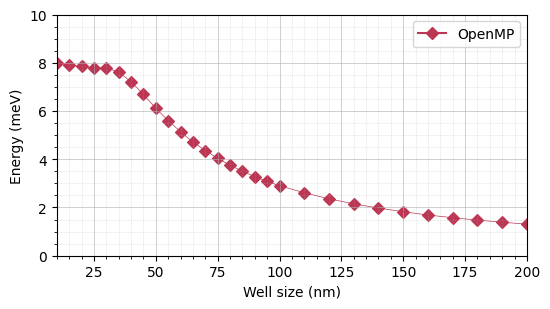

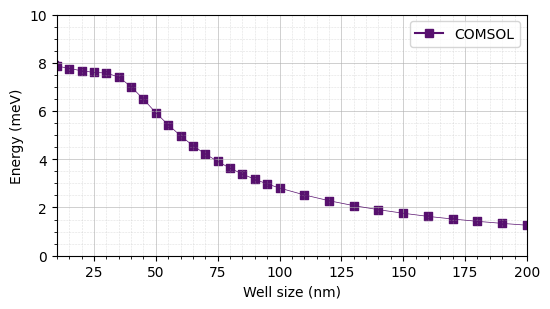

In [17]:
# Leer resultados_1.dat
data1 = np.loadtxt('../DataPrep/resultados_1.dat')
h1_1 = data1[:, 0]
E1 = data1[:, 1]

alp2 = 0.4  # Opacidad de la cuadrícula

# Leer dat_comsol.txt (ignorando líneas que empiezan con %)
df_comsol = pd.read_csv('../DataPrep/dat_comsol.txt', delim_whitespace=True, comment='%', header=None)
df_comsol.columns = ['m', 'B0', 'E0', 'h1', 'E_comsol']

h1_2 = df_comsol['h1']
E2 = df_comsol['E_comsol']

# Crear el subplot
plt.figure(figsize=(xsize, ysize))
cmap = plt.get_cmap("inferno", len(unique_m) + 2)  # Colormap similar al estilo deseado
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H', 'X', 'd']  # Lista de marcadores

c2 = 2
plt.plot(h1_1, E1, linestyle='-', lw=.5, color=cmap(c2), label='OpenMP')
plt.scatter(h1_1, E1, color=cmap(c2), marker=markers[c2])
plt.xlabel("Well size (nm)")
plt.ylabel("Energy (meV)")
# ax.set_title('Comparación de resultados')
# ax.legend()
plt.xlim(10, 200)
plt.ylim(0, 10)
plt.grid(which='major', linestyle='-', linewidth=0.7, alpha=alp2+0.2)
plt.grid(which='minor', linestyle='--', linewidth=0.4, alpha=alp2)
plt.minorticks_on()
plt.legend()

# Mostrar la gráfica con leyenda que incluya el marcador
handles, labels = plt.gca().get_legend_handles_labels()
new_handles = []
for handle, label in zip(handles, labels):
    marker = markers[2]
    new_handles.append(plt.Line2D([], [], color=handle.get_color(), marker=marker, linestyle='-', label=label))
plt.legend(handles=new_handles)

plt.tight_layout()
# plt.savefig(f"output/graph_openmp.pdf", format="pdf", bbox_inches="tight")



# Crear el subplot
plt.figure(figsize=(xsize, ysize))
cmap = plt.get_cmap("inferno", len(unique_m) + 2)  # Colormap similar al estilo deseado
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H', 'X', 'd']  # Lista de marcadores

c1 = 1
plt.plot(h1_2, E2, linestyle='-', lw=.5, color=cmap(c1), label='COMSOL')
plt.scatter(h1_2, E2, color=cmap(c1), marker=markers[c1])
plt.xlabel("Well size (nm)")
plt.ylabel("Energy (meV)")
# ax.set_title('Comparación de resultados')
# ax.legend()
plt.xlim(10, 200)
plt.ylim(0, 10)
plt.grid(which='major', linestyle='-', linewidth=0.7, alpha=alp2+0.2)
plt.grid(which='minor', linestyle='--', linewidth=0.4, alpha=alp2)
plt.minorticks_on()
plt.legend()

# Mostrar la gráfica con leyenda que incluya el marcador
handles, labels = plt.gca().get_legend_handles_labels()
new_handles = []
for handle, label in zip(handles, labels):
    marker = markers[1]
    new_handles.append(plt.Line2D([], [], color=handle.get_color(), marker=marker, linestyle='-', label=label))
plt.legend(handles=new_handles)

plt.tight_layout()
# plt.savefig(f"output/graph_comsol.pdf", format="pdf", bbox_inches="tight")

